In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
np.random.seed(42)
n = 250

df = pd.DataFrame({
    "Student_ID": np.arange(1, n+1),
    "Name": [f"Student_{i}" for i in range(1, n+1)],
    "Gender": np.random.choice(["Male", "Female"], n),
    "Department": np.random.choice(["CSE", "IT", "ECE"], n),
    "Year": np.random.choice(["1st", "2nd", "3rd"], n),
    "Maths": np.random.randint(40, 100, n),
    "Science": np.random.randint(40, 100, n),
    "English": np.random.randint(40, 100, n),
    "Attendance": np.random.randint(50, 100, n),
    "Internal": np.random.randint(10, 25, n)
})

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal
0,1,Student_1,Male,IT,1st,97,67,81,88,11
1,2,Student_2,Female,CSE,2nd,83,81,64,52,20
2,3,Student_3,Male,CSE,2nd,84,61,57,81,19
3,4,Student_4,Male,CSE,2nd,71,60,79,59,16
4,5,Student_5,Male,ECE,3rd,84,45,47,59,10


In [30]:
df["Total"] = df[["Maths", "Science", "English"]].sum(axis=1)
df["Average"] = df["Total"] / 3

conditions = [
    df["Average"] >= 75,
    df["Average"] >= 60,
    df["Average"] >= 50
]
choices = ["A", "B", "C"]

df["Grade"] = np.select(conditions, choices, default="Fail")

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal,Total,Average,Grade
0,1,Student_1,Male,IT,1st,97,67,81,88,11,245,81.666667,A
1,2,Student_2,Female,CSE,2nd,83,81,64,52,20,228,76.000000,A
2,3,Student_3,Male,CSE,2nd,84,61,57,81,19,202,67.333333,B
3,4,Student_4,Male,CSE,2nd,71,60,79,59,16,210,70.000000,B
4,5,Student_5,Male,ECE,3rd,84,45,47,59,10,176,58.666667,C


In [31]:
top_students = df.nlargest(5, "Total")
fail_students = df.query("Grade == 'Fail'")

top_students

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal,Total,Average,Grade
51,52,Student_52,Female,IT,2nd,99,95,94,97,13,288,96.000000,A
189,190,Student_190,Female,ECE,2nd,96,95,92,93,20,283,94.333333,A
219,220,Student_220,Male,IT,1st,87,92,98,61,11,277,92.333333,A
19,20,Student_20,Male,IT,1st,86,96,94,72,16,276,92.000000,A
150,151,Student_151,Male,CSE,3rd,93,88,94,85,20,275,91.666667,A


In [32]:
fail_students

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal,Total,Average,Grade
31,32,Student_32,Male,CSE,1st,62,40,46,73,10,148,49.333333,Fail
90,91,Student_91,Female,CSE,2nd,40,57,44,89,24,141,47.000000,Fail
119,120,Student_120,Male,CSE,1st,42,60,44,61,13,146,48.666667,Fail
156,157,Student_157,Male,CSE,3rd,40,41,48,96,10,129,43.000000,Fail
159,160,Student_160,Female,IT,3rd,44,47,49,54,12,140,46.666667,Fail
172,173,Student_173,Male,CSE,1st,41,59,46,75,18,146,48.666667,Fail
202,203,Student_203,Male,ECE,2nd,43,48,56,96,14,147,49.000000,Fail
232,233,Student_233,Female,IT,2nd,43,47,57,75,20,147,49.000000,Fail
247,248,Student_248,Male,ECE,2nd,60,43,40,79,20,143,47.666667,Fail


In [33]:
dept_perf = df.groupby("Department")["Average"].agg(["mean", "max", "min"])
gender_perf = df.groupby("Gender")["Average"].mean()
year_perf = df.pivot_table(values="Average", index="Year", columns="Department")

dept_perf

,mean,max,min
Department,,,
CSE,68.420635,91.666667,43.000000
ECE,70.012195,94.333333,47.666667
IT,69.857143,96.000000,46.666667


In [34]:
gender_perf

,Average
Gender,
Female,69.755376
Male,69.100529


In [35]:
year_perf

Department,CSE,ECE,IT
Year,,,
1st,69.055556,66.769231,72.000000
2nd,68.180556,71.750000,67.787879
3rd,67.708333,71.208333,68.361111


In [36]:
correlation = df[["Attendance", "Internal", "Average"]].corr()
correlation

,Attendance,Internal,Average
Attendance,1.000000,-0.018177,0.045787
Internal,-0.018177,1.000000,0.060339
Average,0.045787,0.060339,1.000000


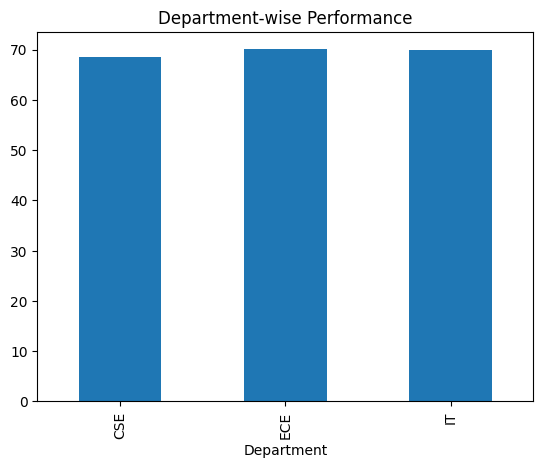

In [37]:
df.groupby("Department")["Average"].mean().plot(kind="bar")
plt.title("Department-wise Performance")
plt.show()

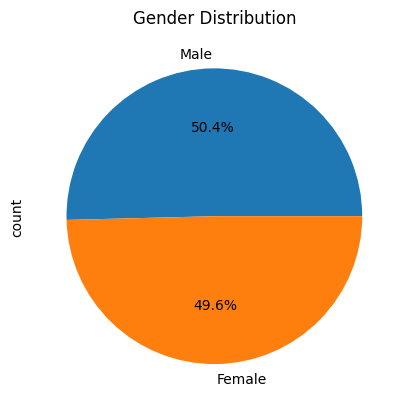

In [38]:
df["Gender"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

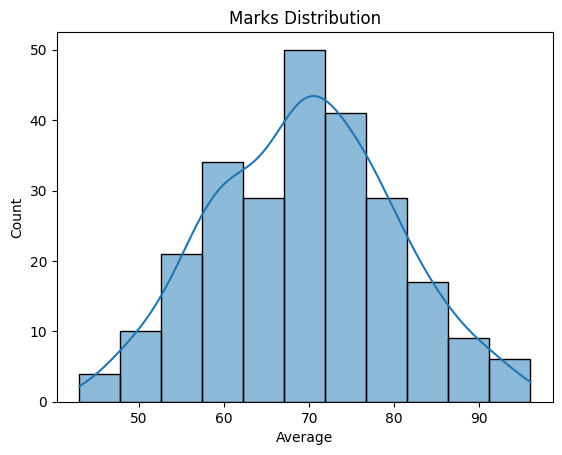

In [39]:
sns.histplot(df["Average"], kde=True)
plt.title("Marks Distribution")
plt.show()

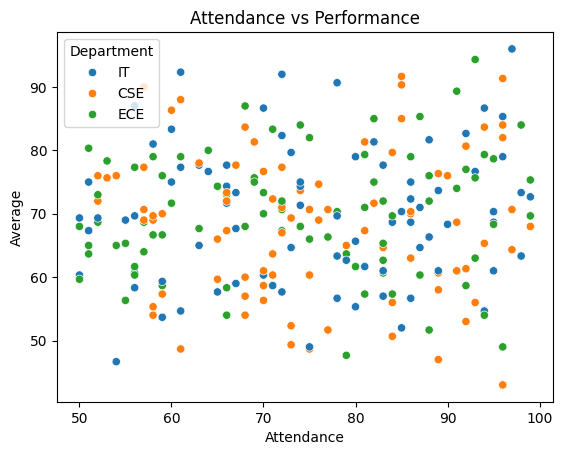

In [40]:
sns.scatterplot(x="Attendance", y="Average", hue="Department", data=df)
plt.title("Attendance vs Performance")
plt.show()

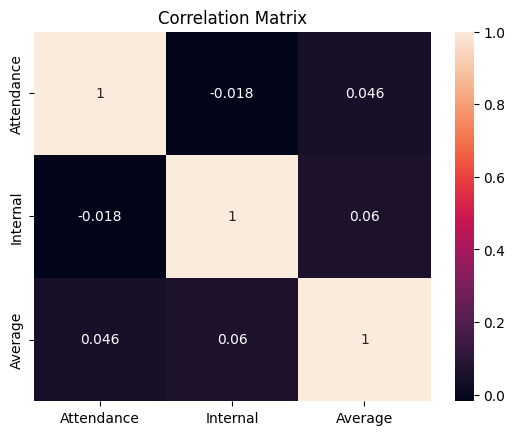

In [41]:
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [42]:
df.to_csv("student_analysis.csv", index=False)